# Detecção de Fraudes em Transações com Machine Learning

## Contexto

Fraudes em transações financeiras representam um grande desafio para instituições financeiras.  
O objetivo deste projeto é construir modelos de machine learning capazes de identificar transações fraudulentas com alta precisão, mesmo em um cenário altamente desbalanceado.

## Objetivo

Desenvolver e comparar modelos de classificação para detectar fraudes em transações de cartão de crédito, priorizando métricas adequadas como Recall e Precision.

## Dataset

O dataset utilizado contém transações reais de cartão de crédito, com variáveis anonimizadas (V1 a V28), além de:

- Time
- Amount
- Class (0 = normal, 1 = fraude)

O dataset é altamente desbalanceado, com menos de 1% de fraudes.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

# Dataset
df = pd.read_csv("creditcard.csv")

print("Shape:", df.shape)

# Info geral
print("\nGeneral Info:")
df.info()

# Valores nulos
print("\nValores nulos:")
print(df.isnull().sum())

df.head()

## Análise Exploratória - EDA

Nesta etapa analisamos a distribuição das classes e identificamos o forte desbalanceamento do dataset.

In [ ]:
# Distribuição de Classes
df["Class"].value_counts().plot(kind="bar")
plt.title("Distribuição de Classes")
plt.show()

print("Distribuição de Classes (%):")
print(df["Class"].value_counts(normalize=True) * 100)

# Distribuição do Amount
plt.hist(df["Amount"], bins=50)
plt.title("Distribuição do Valor das Transações")
plt.show()

## Feature Engineering

Aplicamos transformação logarítmica na variável Amount para melhorar a distribuição.

In [ ]:
df["amount_log"] = np.log1p(df["Amount"])

plt.hist(df["amount_log"], bins=50)
plt.title("Distribuição Log do Amount")
plt.show()

## Preparação dos Dados

Separação entre variáveis de entrada (X) e target (y), com divisão treino/teste usando stratify.

In [ ]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

## Modelo 1 — Logistic Regression

In [ ]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=300))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

print(classification_report(y_test, y_pred))

## Ajuste de Threshold

In [ ]:
y_prob = pipeline.predict_proba(X_test)[:, 1]

threshold = 0.3
y_pred_custom = (y_prob >= threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

## Modelo 2 — Random Forest

In [ ]:
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

## Modelo 3 — XGBoost

In [ ]:
!pip install xgboost -q

from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))

## Balanceamento de Dados com SMOTE

Para lidar com o desbalanceamento do dataset, utilizamos a técnica SMOTE (Synthetic Minority Over-sampling Technique).

Essa técnica gera novos exemplos sintéticos da classe minoritária (fraudes), permitindo que o modelo aprenda melhor os padrões associados a esse tipo de evento.

Isso pode melhorar significativamente o recall do modelo.

In [43]:
with open('requirements.txt', 'w') as f:
    f.write('pandas\n')
    f.write('numpy\n')
    f.write('matplotlib\n')
    f.write('scikit-learn\n')
    f.write('xgboost\n')
    f.write('imbalanced-learn\n')

print('requirements.txt gerado com sucesso!')

requirements.txt gerado com sucesso!


## Visualização da Curva ROC Comparativa

Vamos plotar as curvas ROC para todos os modelos para uma comparação visual do desempenho.

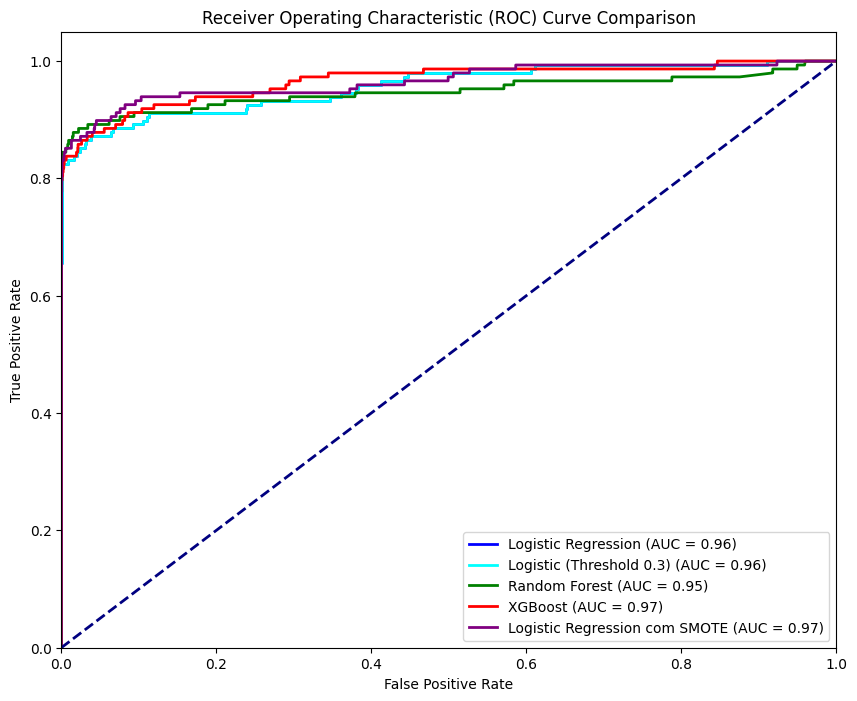

In [44]:
plt.figure(figsize=(10, 8))

def plot_roc_curve(model_name, y_true, y_proba, color):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = roc_auc_score(y_true, y_proba)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{model_name} (AUC = {roc_auc:.2f})')

plot_roc_curve('Logistic Regression', y_test, pipeline.predict_proba(X_test)[:, 1], 'blue')
plot_roc_curve('Logistic (Threshold 0.3)', y_test, pipeline.predict_proba(X_test)[:, 1], 'cyan')
plot_roc_curve('Random Forest', y_test, rf.predict_proba(X_test)[:, 1], 'green')
plot_roc_curve('XGBoost', y_test, xgb.predict_proba(X_test)[:, 1], 'red')
plot_roc_curve('Logistic Regression com SMOTE', y_test, pipeline_smote.predict_proba(X_test)[:, 1], 'purple')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc="lower right")
plt.show()

## Análise do Trade-off Precision-Recall com SMOTE

Ao aplicar o SMOTE para balancear os dados, observamos um aumento significativo no Recall (capacidade de detectar fraudes), mas com uma queda na Precision (número de falsos positivos).

No contexto de detecção de fraudes, um Recall alto é frequentemente mais desejável, pois o custo de não detectar uma fraude real é geralmente maior do que o custo de investigar um falso positivo. No entanto, é crucial encontrar um equilíbrio que não sobrecarregue a equipe de investigação com muitos alertas falsos. O modelo de Regressão Logística com SMOTE, embora tenha um Recall impressionante, mostra que essa melhoria vem com um sacrifício na Precision, o que precisa ser considerado em um cenário de negócio real.

In [ ]:
!pip install imbalanced-learn -q

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

pipeline_smote = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=300))
])

pipeline_smote.fit(X_train_sm, y_train_sm)

y_pred_smote = pipeline_smote.predict(X_test)

print(classification_report(y_test, y_pred_smote))

## Comparação de Modelos

In [ ]:
resultados = []

# Logistic Regression padrão
report_lr = classification_report(y_test, y_pred, output_dict=True)
roc_lr = roc_auc_score(y_test, pipeline.predict_proba(X_test)[:, 1])

resultados.append({
    "Modelo": "Logistic Regression",
    "Precision": report_lr["1"]["precision"],
    "Recall": report_lr["1"]["recall"],
    "F1-score": report_lr["1"]["f1-score"],
    "ROC-AUC": roc_lr
})

# Logistic com threshold
report_thr = classification_report(y_test, y_pred_custom, output_dict=True)

resultados.append({
    "Modelo": "Logistic (Threshold 0.3)",
    "Precision": report_thr["1"]["precision"],
    "Recall": report_thr["1"]["recall"],
    "F1-score": report_thr["1"]["f1-score"],
    "ROC-AUC": roc_lr
})

# Random Forest
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)
roc_rf = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])

resultados.append({
    "Modelo": "Random Forest",
    "Precision": report_rf["1"]["precision"],
    "Recall": report_rf["1"]["recall"],
    "F1-score": report_rf["1"]["f1-score"],
    "ROC-AUC": roc_rf
})

# XGBoost
report_xgb = classification_report(y_test, y_pred_xgb, output_dict=True)
roc_xgb = roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1])

resultados.append({
    "Modelo": "XGBoost",
    "Precision": report_xgb["1"]["precision"],
    "Recall": report_xgb["1"]["recall"],
    "F1-score": report_xgb["1"]["f1-score"],
    "ROC-AUC": roc_xgb
})

# Logistic Regression com SMOTE
report_smote = classification_report(y_test, y_pred_smote, output_dict=True)
roc_smote = roc_auc_score(y_test, pipeline_smote.predict_proba(X_test)[:, 1])

resultados.append({
    "Modelo": "Logistic Regression com SMOTE",
    "Precision": report_smote["1"]["precision"],
    "Recall": report_smote["1"]["recall"],
    "F1-score": report_smote["1"]["f1-score"],
    "ROC-AUC": roc_smote
})

df_resultados = pd.DataFrame(resultados)

df_resultados.sort_values(by="Recall", ascending=False)

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = pipeline.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("Curva ROC")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

print("ROC AUC:", roc_auc_score(y_test, y_prob))

## Recomendação Final do Modelo

Considerando os objetivos de negócio de priorizar o Recall para detecção de fraudes, os modelos **Random Forest** e **XGBoost** apresentaram o melhor equilíbrio entre Recall e Precision, com ROC-AUCs elevados, indicando boa capacidade de discriminação.

O **XGBoost** se destacou com a maior Precision (0.94) entre os modelos que mantiveram um Recall satisfatório (0.73), além do maior ROC-AUC (0.97). Isso sugere que ele é o mais promissor para identificar fraudes de forma eficaz, minimizando falsos positivos.

O **Random Forest** também é uma excelente opção, com Recall ligeiramente superior (0.76) e uma Precision ainda muito boa (0.83).

Para um ambiente de produção, seria recomendado iniciar com o **XGBoost** ou **Random Forest**, talvez com um ajuste fino de seus parâmetros e thresholds, buscando otimizar ainda mais o trade-off entre Recall e Precision de acordo com as políticas da instituição financeira.

## Interpretação de Negócio

Em cenários reais de fraude, o custo de não identificar uma transação fraudulenta é muito maior do que o custo de um falso positivo.

Por isso, métricas como Recall são mais importantes do que acurácia.

Um modelo com alta acurácia pode parecer bom, mas se ele não detectar fraudes, ele não gera valor para o negócio.

Neste projeto, priorizamos modelos e ajustes que aumentam a detecção de fraudes, mesmo com um pequeno aumento de falsos positivos.

## Conclusão

Modelos mais robustos apresentaram melhor desempenho.

O ajuste de threshold e o uso de SMOTE aumentaram a capacidade de detectar fraudes.

Este projeto reforça a importância de escolher métricas corretas em problemas desbalanceados.